# Single neuron with 3 types of inputs

We simulate a synthetic neuron with three recorded inputs:

* Position $x_t$ drives the firing rate through a curved tuning function $f_{\mathrm{pos}}$.
* Discrete events $e_t$ raise the rate for a few hundred milliseconds, through the response $k$. Events can be e.g. incoming spikes or some perturbations in the experiment.
* A nuisance input $n_t$ has no effect on the firing rate. E.g. speed, head direction, etc. It is correlated with position: in each bin, the two are drawn together from a 2D Gaussian with correlation 0.9, then rescaled to $[-2, 2]$.

In each time bin $t$, the spike count $y_t$ comes from:

$$\log \lambda_t = \beta_0 + f_{\mathrm{pos}}(x_t) + \sum_{\tau \ge 0} k(\tau)\, e_{t-\tau}$$

$$y_t \sim \mathrm{Poisson}(\lambda_t)$$

* $\beta_0$ is the baseline log-rate.
* $f_{\mathrm{pos}}(x)$ is a Gaussian bump centered at 0.
* $e_t$ is 1 if an event falls in bin $t$, else 0.
* $k(\tau)$ is the response to one event, $\tau$ bins later. It has a gamma shape, with a peak at about 260 ms. It is close to zero after 1.2 s.
* The nuisance input $n_t$ does not appear in the equation, so it does not influence the firing rate.

In [1]:
import jax
import matplotlib.pyplot as plt
import nemos as nmo
import numpy as np
import pandas as pd
from example_data import (
    EVENT_WINDOW_SIZE,
    make_event_impulse,
    make_temporal_dataset,
)
from example_plots import (
    hide_file_paths_in_warnings,
    plot_binned_tuning,
    plot_design_blocks,
    plot_inputs_and_counts_over_time,
    plot_predicted_and_true_rate,
    plot_recovered_smooths,
    plot_true_effects,
    set_plot_style,
)

from pgam_jax import GAM

jax.config.update("jax_enable_x64", True)
set_plot_style()
hide_file_paths_in_warnings()

## Generate toy data

120 seconds of data binned at 10 ms into 12000 time bins. 180 events. The plot
shows the first 20 seconds.

Time bins: 12000
Events: 180
Total spikes: 5235


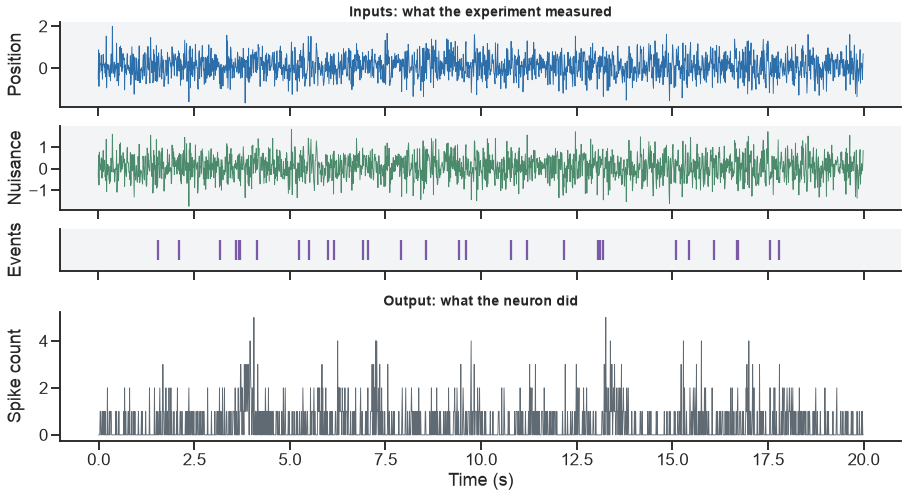

In [2]:
data = make_temporal_dataset(spatial_nuisance_correlation=0.9)
print(f"Time bins: {data.y.size}")
print(f"Events: {int(data.events.sum())}")
print(f"Total spikes: {int(data.y.sum())}")

fig = plot_inputs_and_counts_over_time(data)
plt.show()

## What the model must recover

The three true effects from the equation above: $f_{\mathrm{pos}}$, zero for the nuisance input, and $k$.

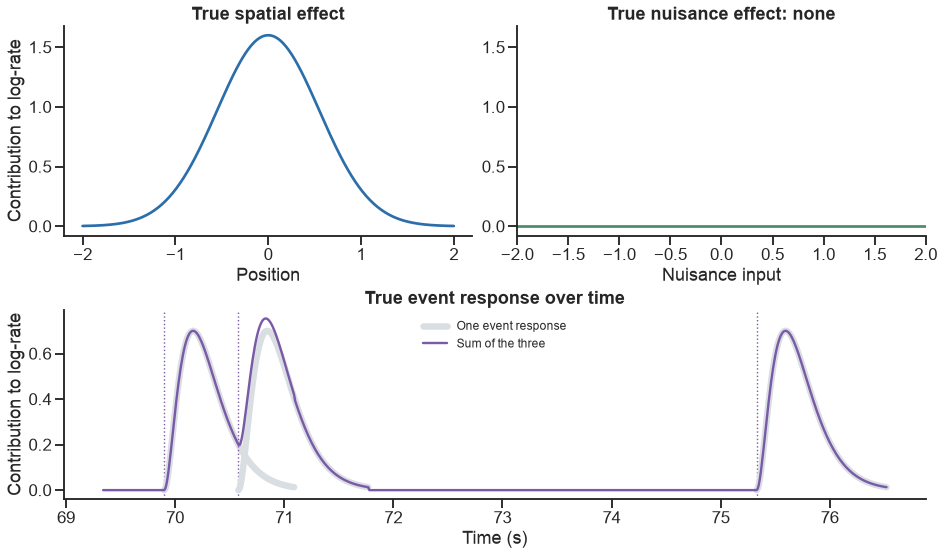

In [3]:
value_grid = np.linspace(-2.0, 2.0, 400)

fig = plot_true_effects(data, value_grid)
plt.show()

### Initial analysis

For position and nuisance: average spikes per input value to get an estimate of the tuning curve.
Position has a clear effect. As it is correlated to position, the nuisance input also seems to, even though we know it does not influence firing.

The events act over time, so calculate an event-triggered average: cut the recording around each event and average those pieces.
It shows a rise, a peak near 250 ms, and a decay back to the baseline.

This figure is the raw version of what the model must recover.
The model does more.
Events that fall close together share part of their window, and
their responses add up here.
The model separates them, and it separates them from the effect of position at the same time.

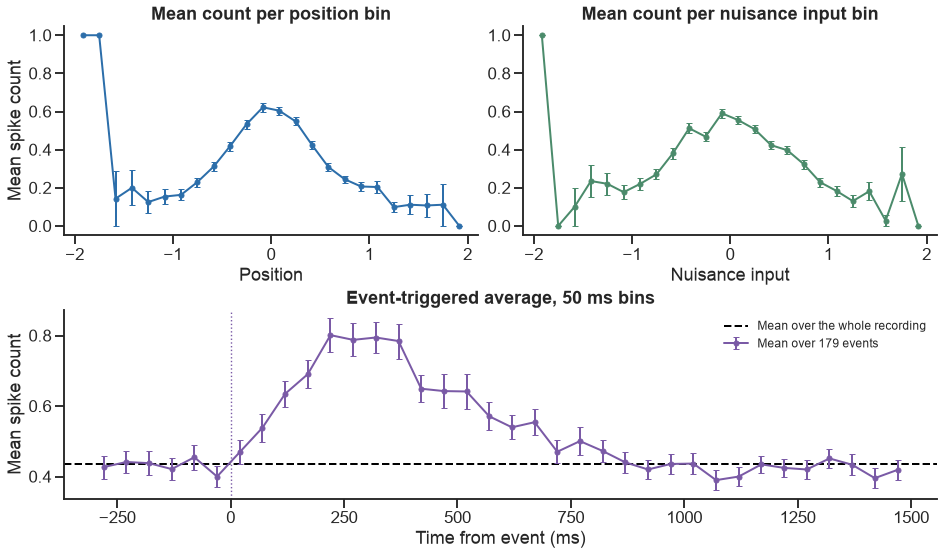

In [4]:
fig = plot_binned_tuning(data)
plt.show()

## Fit the model

### Build the basis

As their effect depends on the current value, for position and the nuisance input we use evaluation bases.
For the event train we use a convolutional basis.

Adding bases builds the additive model. Each term keeps its own label and its
own smoothing strength.

In [5]:
spatial_basis = nmo.basis.BSplineEval(
    11,
    bounds=(-2.0, 2.0),
    label="position",
)
nuisance_basis = nmo.basis.BSplineEval(
    11,
    bounds=(-2.0, 2.0),
    label="nuisance",
)
event_basis = nmo.basis.BSplineConv(
    8,
    window_size=EVENT_WINDOW_SIZE,  # in bins
    label="event history",
)

In [6]:
full_basis = spatial_basis + nuisance_basis + event_basis

### The design matrix

Each block of columns belongs to one smooth. The event block starts with 120
NaN rows, drawn in orange. A convolution needs a full window of past samples,
so those rows have no value yet. The default `nan_handling="zero"` replaces
them with zero and keeps the rows. Pass `nan_handling="drop"` to `GAM` to
remove those rows instead.

**TIP:** If your data has trials, the event response must not cross a trial
border. Wrap each input in a `pynapple` `Tsd` with the trial intervals as its
`time_support`. Pass these objects to `compute_features`, `fit`, and `predict`
in place of the arrays. `nemos` then runs the convolution inside each trial
separately, and each trial starts with its own block of NaN rows.

In [7]:
design = full_basis.compute_features(data.position, data.nuisance, data.events)
print(f"Design matrix shape: {design.shape}")

Design matrix shape: (12000, 30)


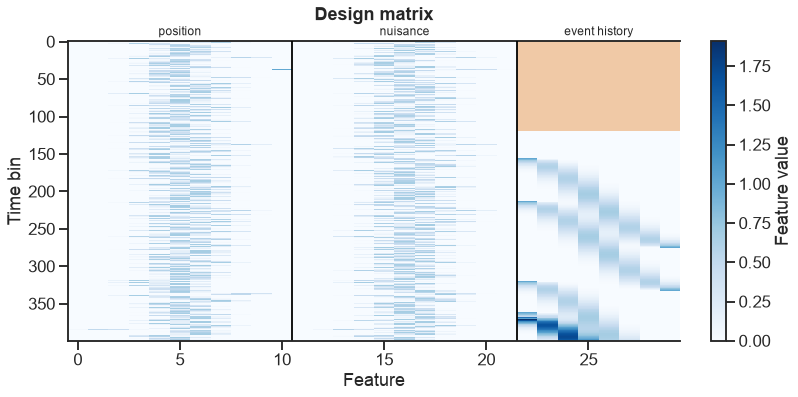

In [8]:
fig = plot_design_blocks(full_basis, data)
plt.show()

### Create the GAM

In [9]:
gam = GAM(
    full_basis,
    use_scipy=True,  # can be faster on CPU
)

### Check concurvity

Concurvity is the version of collinearity for smooths.
For each smooth, it measures how much of that smooth the other smooths in the model can reproduce.
0 means that the smooth is fully identifiable. 1 means that the other smooths can fully replace it.
High concurvity makes the estimates of individual smooths, and their p-values, unreliable, even when the model as a whole fits well.

`gam.concurvity` returns these measures, each between 0 and 1:

* `worst`: the worst case over all possible coefficients. Pessimistic.
* `estimate`: a summary that depends only on the design matrix, not on the coefficients.
* `observed`: the value at the fitted coefficients. Available only after `fit`. Can be optimistic.

The `para` row is the intercept.

In [10]:
concurvity_df = gam.concurvity(
    (data.position, data.nuisance, data.events), as_dataframe=True
)
concurvity_df.style.format("{:.2f}")

,worst,estimate
term,,
para,0.00,0.00
position,0.82,0.61
nuisance,0.82,0.60
event history,0.00,0.00


Position and nuisance have high concurvity, because the two inputs are correlated.
The same correlation made the nuisance input look tuned in the initial analysis.
The event history has no concurvity with the other smooths.

Can the model still tell position and nuisance apart? The results after the fit answer this.

### Fit the GAM

In [11]:
gam.fit(
    (data.position, data.nuisance, data.events),
    data.y,
)

## The estimated smoothing strengths

Each smooth is regularized separately.

In `pgam_jax` each smooth gets two regularization parameters:

* The curvature strength penalizes wiggliness.
* Linear functions are not penalized by the curvature penalty, i.e. they are in its null space, so a second penalty is added. A large value here pulls the whole smooth toward zero.

A large lambda means a strong penalty, so a flatter shape.
The nuisance smooth gets very large values for both parts, indicating that it is pulled to zero.

In [12]:
# regularizer_strength_ holds log lambda, one (wiggliness, null space) pair per smooth
pd.DataFrame(
    np.exp(np.stack(gam.regularizer_strength_)),
    index=[component.label for component in gam.basis],
    columns=["wiggliness", "null space"],
).style.format("{:.3g}")

,wiggliness,null space
position,0.154,9.05e+05
nuisance,6.95e+08,4.77e+06
event history,0.0258,2.98


## Effective degrees of freedom

The smoothing strengths are hard to read directly.
The effective degrees of freedom (EDF) turn them into one number per smooth: about how many free parameters the smooth really uses after the penalty.

* With no penalty, the EDF would equal the number of coefficients. That is 10 for position and nuisance (11 basis functions, one dropped for identifiability) and 8 for the event history.
* A stronger penalty lowers the EDF. An EDF near 1 means a straight line. An EDF near 0 means that the smooth is pulled to zero.

This also shows that the model switched the nuisance smooth off.

In [13]:
smooth_labels = ["position", "nuisance", "event history"]

for label in smooth_labels:
    edf = gam.edf_of_component(label)
    print(f"{label:>14}: {edf:.3g}")

      position: 4.88
      nuisance: 1.07e-06
 event history: 6.81


## Significance of each smooth

`test_smooth_significance` tests the null hypothesis that a smooth is zero
over its whole domain, so it does not contribute to the firing rate.

In [14]:
p_values = {}
for label in smooth_labels:
    pval = gam.test_smooth_significance(label)

    p_values[label] = float(pval)
    print(f"{label:>14}: {p_values[label]:.3g}")

      position: 0
      nuisance: 1
 event history: 0


Position and event history get p-values near zero. The nuisance smooth gets a large p-value, so we cannot reject that it is zero.

The p-values are approximate. Read them with these cautions:

* The test treats the fitted smoothing strengths as fixed and ignores their uncertainty. Read a p-value close to the threshold (for example 0.05) as inconclusive. The `UserWarning` above says this.
* A p-value of 0 means that the true value is smaller than the numerical integration can resolve. It does not mean exactly zero.
* High concurvity can make the test unreliable. Position and nuisance have high concurvity (see above). Here the data was enough to separate them: the nuisance smooth is pulled to zero, and its p-value is large.

## GAM recovers the true smooths

`gam.smooth_compute` evaluates each smooth's contribution to the log-rate.

In [15]:
position_smooth = gam.smooth_compute(value_grid, "position")
nuisance_smooth = gam.smooth_compute(value_grid, "nuisance")

# evaluate the temporal smooth in response to a single event
impulse, event_time_ms = make_event_impulse()
event_smooth = gam.smooth_compute(impulse, "event history")

`gam.smooth_compute` returns the mean and a confidence band around it:

In [16]:
print(len(position_smooth))
print(position_smooth[0].shape)  # mean
print(position_smooth[1].shape)  # lower
print(position_smooth[2].shape)  # upper

3
(400,)
(400,)
(400,)


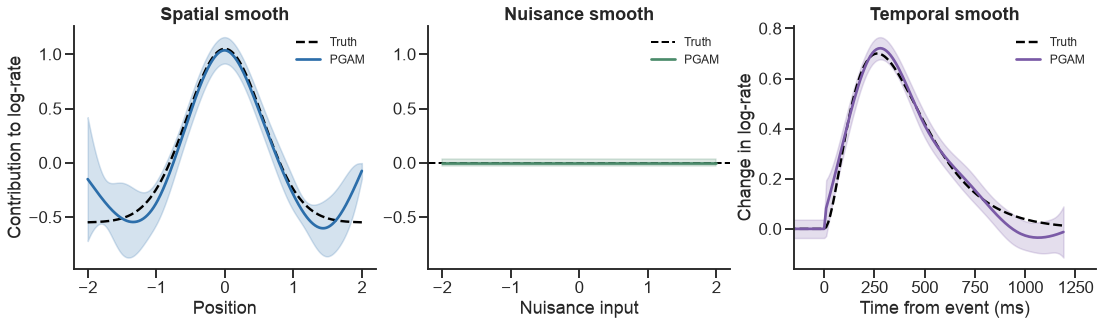

In [17]:
fig = plot_recovered_smooths(
    data,
    value_grid,
    position_smooth,
    nuisance_smooth,
    event_smooth,
    impulse,
    event_time_ms,
)
plt.show()

Note that on these plots, the spatial and nuisance curves have mean zero over `value_grid`, and the event curves are shifted to be zero before the event.
The model recovers only the shape of the spatial and nuisance effects, not their level.
A constant can move between a smooth and the intercept without any change to the predicted rate.
In contrast, the event response has a known level, because its contribution is zero when no event falls in the window.

## Predicted rate over time

`gam.predict` combines all smooths and the intercept into the expected spike count in each bin.
Pass the whole recording, because the event term needs the past samples.
Then compare the first 3 seconds with the true rate.
The rate jumps from bin to bin because position is drawn independently in each bin.

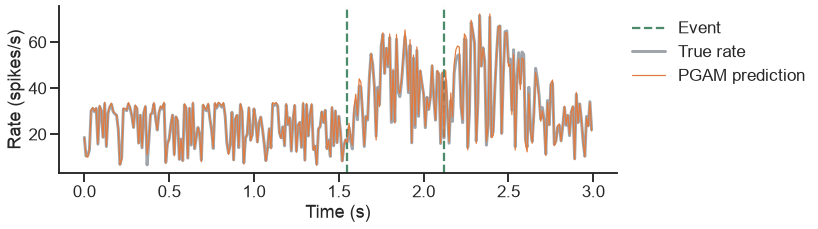

In [18]:
# Divide by the bin width to convert the count per bin to spikes/s.
predicted_rate = (
    gam.predict((data.position, data.nuisance, data.events)) / data.time_bin
)

fig = plot_predicted_and_true_rate(data, predicted_rate)
plt.show()